In [1]:
# SECTION 0: Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# SECTION 1: Setup Output Directory
# All plots and outputs will be saved here
out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)
print(f"Output folder ready: {out_dir}")

Output folder ready: outputs


In [3]:
# SECTION 2: Data Loading
# Load UCI Wine dataset directly from UCI repository
# 178 samples, 13 features, 3 wine classes
url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/wine/wine.data"
)

column_names = [
    "Class label", "Alcohol", "Malic acid", "Ash",
    "Alcalinity of ash", "Magnesium", "Total phenols",
    "Flavanoids", "Nonflavanoid phenols", "Proanthocyanins",
    "Color intensity", "Hue",
    "OD280/OD315 of diluted wines", "Proline"
]

df = pd.read_csv(url, header=None, names=column_names)

print(f"Dataset Shape   : {df.shape}")
print(f"Number of rows  : {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1}")
print(f"Classes         : {df['Class label'].unique()}")
print("\nFirst 5 rows:")
df.head()

Dataset Shape   : (178, 14)
Number of rows  : 178
Number of features: 13
Classes         : [1 2 3]

First 5 rows:


,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
# SECTION 3: Exploratory Data Analysis (EDA)
# Understand the dataset before modelling
print("Basic Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["Class label"].value_counts())

Basic Statistics:
       Class label     Alcohol  Malic acid         Ash  Alcalinity of ash  \
count   178.000000  178.000000  178.000000  178.000000         178.000000   
mean      1.938202   13.000618    2.336348    2.366517          19.494944   
std       0.775035    0.811827    1.117146    0.274344           3.339564   
min       1.000000   11.030000    0.740000    1.360000          10.600000   
25%       1.000000   12.362500    1.602500    2.210000          17.200000   
50%       2.000000   13.050000    1.865000    2.360000          19.500000   
75%       3.000000   13.677500    3.082500    2.557500          21.500000   
max       3.000000   14.830000    5.800000    3.230000          30.000000   

        Magnesium  Total phenols  Flavanoids  Nonflavanoid phenols  \
count  178.000000     178.000000  178.000000            178.000000   
mean    99.741573       2.295112    2.029270              0.361854   
std     14.282484       0.625851    0.998859              0.124453   
min     

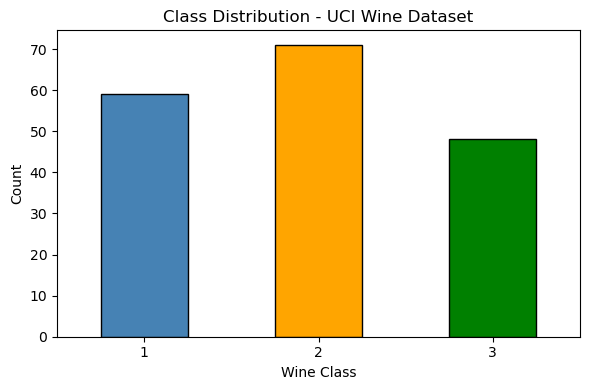

Saved: eda_class_distribution.png


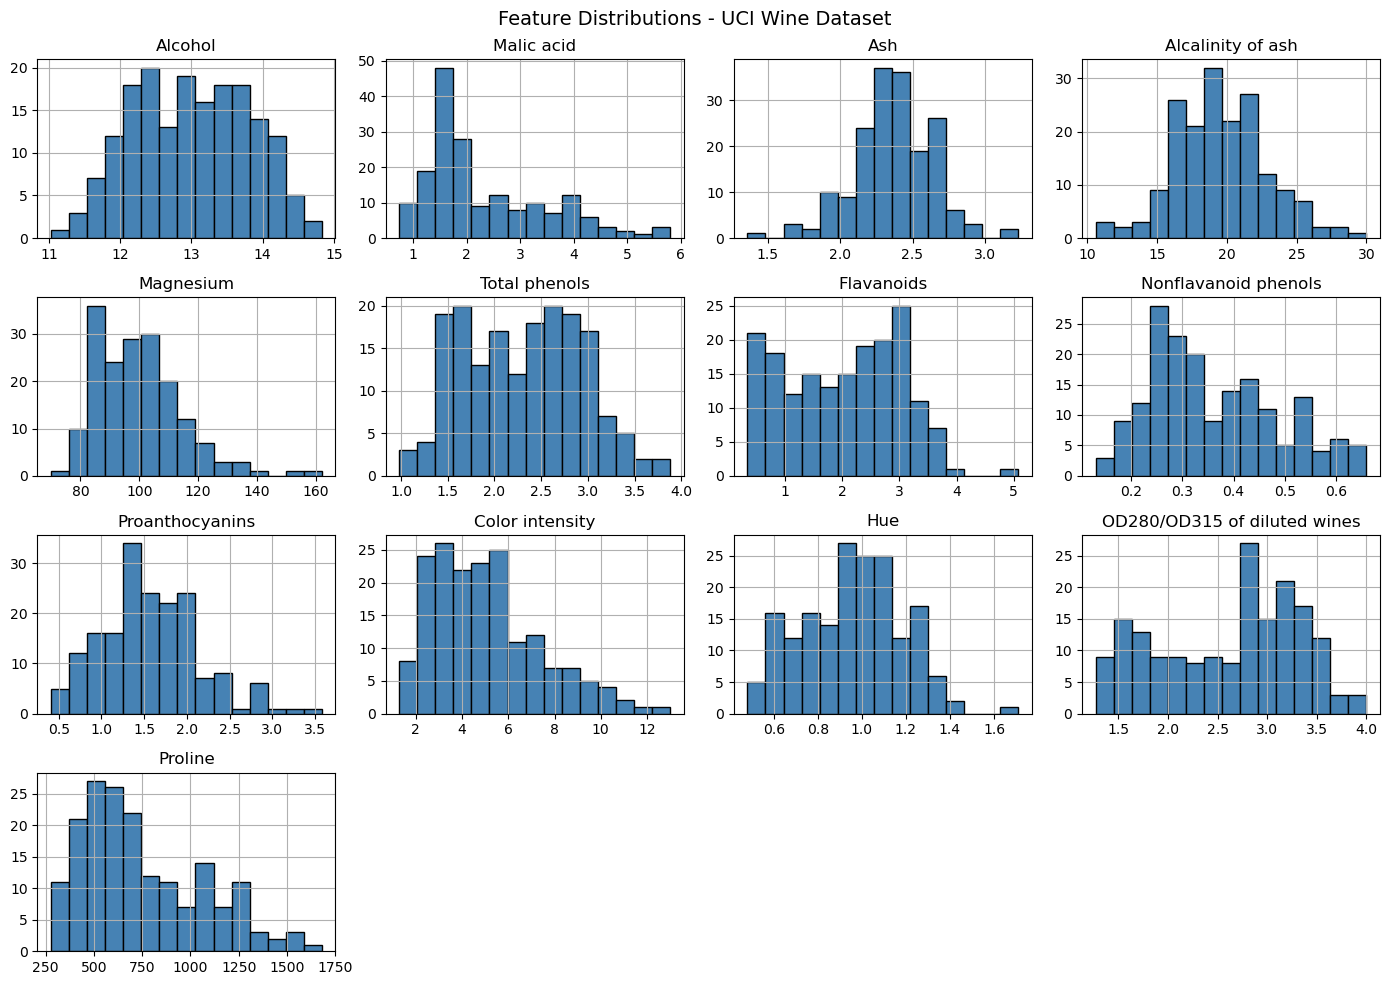

Saved: eda_feature_distributions.png


In [5]:
# Plot 1: Class distribution
plt.figure(figsize=(6, 4))
df["Class label"].value_counts().sort_index().plot(
    kind="bar",
    color=["steelblue", "orange", "green"],
    edgecolor="black"
)
plt.title("Class Distribution - UCI Wine Dataset")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "eda_class_distribution.png"), dpi=300)
plt.show()
print("Saved: eda_class_distribution.png")

# Plot 2: Feature distributions
df.iloc[:, 1:].hist(
    bins=15,
    figsize=(14, 10),
    color="steelblue",
    edgecolor="black"
)
plt.suptitle("Feature Distributions - UCI Wine Dataset", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "eda_feature_distributions.png"), dpi=300)
plt.show()
print("Saved: eda_feature_distributions.png")

In [6]:
# SECTION 4: Data Pre-processing
# Separate features (X) and target (y)
# Split 70% training / 30% testing
# Apply StandardScaler for Logistic Regression only
# Decision Tree does NOT need scaling
# --------------------------------------------------------------

# Separate features and target
X = df.iloc[:, 1:].values       # All columns except Class label
y = df.iloc[:, 0].values        # Class label column
feature_names = df.columns[1:]  # Feature names for plots

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")

# Train/test split
# stratify=y ensures equal class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

# Feature Scaling (for Logistic Regression only)
# fit_transform on training -> learns mean and std
# transform on test -> applies same scaling (no data leakage)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

print("\nStandardScaler applied")
print("Mean of scaled training features (should be ~0):")
print(X_train_std.mean(axis=0).round(2))

Features shape : (178, 13)
Target shape   : (178,)

Training samples : 124
Testing samples  : 54

StandardScaler applied
Mean of scaled training features (should be ~0):
[ 0.  0.  0.  0. -0.  0.  0. -0.  0. -0.  0.  0. -0.]


In [21]:
# SECTION 5: Technique 1 - Logistic Regression
# L1 penalty-> forces some weights to exactly 0 (feature selection)
# L2 penalty-> shrinks all weights but keeps them
# C-> inverse regularization strength (smaller C = stronger penalty)
# ------------------------------------------------------------------

# Logistic Regression with L1
lr_l1 = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="liblinear",
    max_iter=2000,
    random_state=42
)
lr_l1.fit(X_train_std, y_train)

# Logistic Regression with L2
lr_l2 = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=2000,
    random_state=42
)
lr_l2.fit(X_train_std, y_train)

# Logistic Regression with L2
lr_l2 = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=2000,        
    random_state=42
)
lr_l2.fit(X_train_std, y_train)

# Predictions
pred_l1 = lr_l1.predict(X_test_std)
pred_l2 = lr_l2.predict(X_test_std)

# Metrics
acc_l1 = accuracy_score(y_test, pred_l1)
acc_l2 = accuracy_score(y_test, pred_l2)
f1_l1  = f1_score(y_test, pred_l1, average="macro")
f1_l2  = f1_score(y_test, pred_l2, average="macro")

print("=== Logistic Regression L1 ===")
print(f"Accuracy : {acc_l1:.4f}")
print(f"F1-macro : {f1_l1:.4f}")
print(classification_report(y_test, pred_l1))

print("=== Logistic Regression L2 ===")
print(f"Accuracy : {acc_l2:.4f}")
print(f"F1-macro : {f1_l2:.4f}")
print(classification_report(y_test, pred_l2))

=== Logistic Regression L1 ===
Accuracy : 0.9815
F1-macro : 0.9829
              precision    recall  f1-score   support

           1       0.95      1.00      0.97        18
           2       1.00      0.95      0.98        21
           3       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

=== Logistic Regression L2 ===
Accuracy : 0.9815
F1-macro : 0.9829
              precision    recall  f1-score   support

           1       0.95      1.00      0.97        18
           2       1.00      0.95      0.98        21
           3       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



L1 Coefficients:
         Alcohol  Malic acid     Ash  Alcalinity of ash  Magnesium  \
Class 1   1.4259      0.1401  0.7074            -1.2580        0.0   
Class 2  -1.4624     -0.4396 -1.2117             0.6158        0.0   
Class 3   0.0000      0.3974  0.3282             0.0000        0.0   

         Total phenols  Flavanoids  Nonflavanoid phenols  Proanthocyanins  \
Class 1            0.0      1.3933                   0.0          -0.0586   
Class 2            0.0      0.0000                   0.0           0.6487   
Class 3            0.0     -2.2544                   0.0          -0.0696   

         Color intensity     Hue  OD280/OD315 of diluted wines  Proline  
Class 1           0.0000  0.0000                        0.4249   1.9808  
Class 2          -1.7057  1.2269                        0.0000  -1.9817  
Class 3           1.7131 -1.0896                       -0.1570   0.0000  

Top 5 Most Influential Features per Class (L1):

  Class 1:
    Proline                         

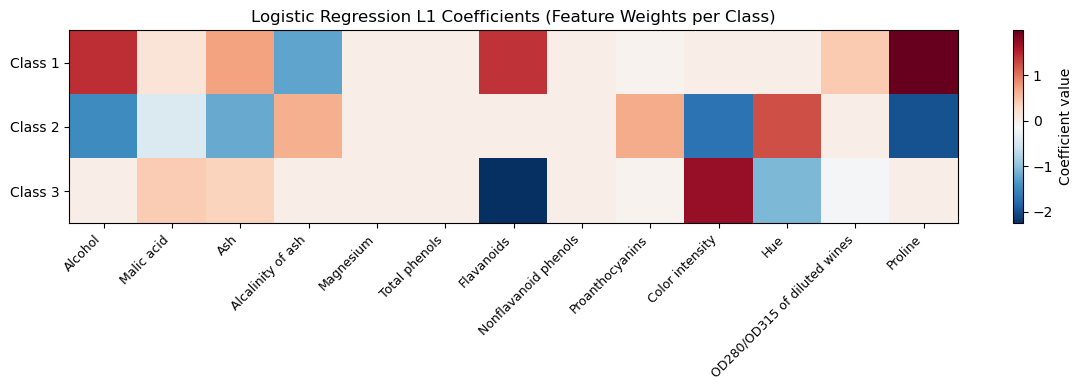

Saved: lr_l1_coefficients_heatmap.png


In [10]:
# SECTION 5.1: Explainability - Logistic Regression Coefficients
# Positive coefficient -> feature pushes prediction toward class
# Negative coefficient -> feature pushes prediction away from class
# Zero coefficient (L1) -> feature not useful for that class
# ----------------------------------------------------------------

coef_df = pd.DataFrame(
    lr_l1.coef_,
    columns=feature_names,
    index=[f"Class {c}" for c in lr_l1.classes_]
)
print("L1 Coefficients:")
print(coef_df.round(4))

# Top 5 features per class
print("\nTop 5 Most Influential Features per Class (L1):")
for cls in coef_df.index:
    top5 = coef_df.loc[cls].abs().sort_values(ascending=False).head(5)
    print(f"\n  {cls}:")
    for feat in top5.index:
        print(f"    {feat:35s} {coef_df.loc[cls, feat]:+.4f}")

# Coefficient heatmap
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(lr_l1.coef_, aspect="auto", cmap="RdBu_r")
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(lr_l1.classes_)))
ax.set_yticklabels([f"Class {c}" for c in lr_l1.classes_])
plt.colorbar(im, ax=ax, label="Coefficient value")
plt.title("Logistic Regression L1 Coefficients (Feature Weights per Class)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "lr_l1_coefficients_heatmap.png"), dpi=300)
plt.show()
print("Saved: lr_l1_coefficients_heatmap.png")

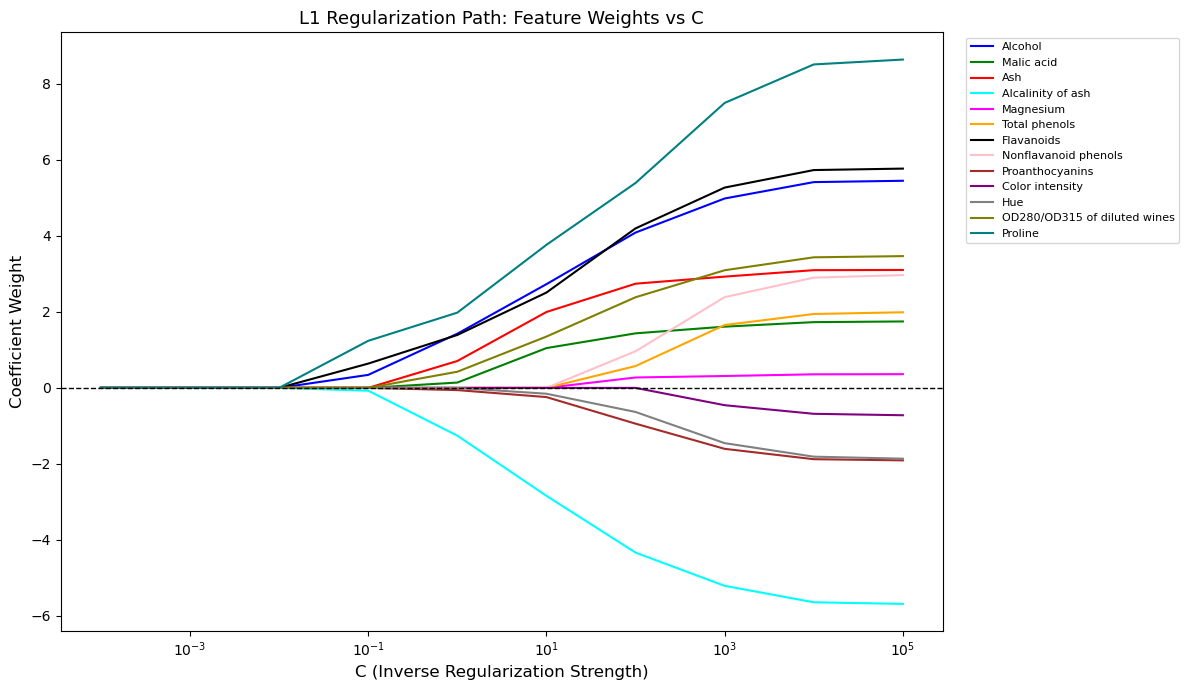

Saved: lr_l1_regularization_path.png


In [12]:
#SECTION 5.2: Explainability - Regularization Path
# Shows how weights change as C (regularization) changes
# Small C -> strong regularization -> more weights become 0
# Large C -> weak regularization  -> all weights kept
# ----------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

c_values       = 10.0 ** np.arange(-4, 6)
weights_over_c = []

for c in c_values:
    temp = LogisticRegression(
        penalty="l1",
        C=c,
        solver="liblinear",
        max_iter=2000,
        random_state=42
    )
    temp.fit(X_train_std, y_train)
    weights_over_c.append(temp.coef_[0])   # Class 1 weights

weights_over_c = np.array(weights_over_c)

colors = [
    "blue", "green", "red", "cyan", "magenta",
    "orange", "black", "pink", "brown", "purple",
    "gray", "olive", "teal"
]

plt.figure(figsize=(12, 7))
for i, feat in enumerate(feature_names):
    plt.plot(c_values, weights_over_c[:, i], label=feat, color=colors[i])
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xscale("log")
plt.xlabel("C (Inverse Regularization Strength)", fontsize=12)
plt.ylabel("Coefficient Weight", fontsize=12)
plt.title("L1 Regularization Path: Feature Weights vs C", fontsize=13)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "lr_l1_regularization_path.png"), dpi=300)
plt.show()
print("Saved: lr_l1_regularization_path.png")

In [13]:
# SECTION 6: Technique 2 - Decision Tree
# Explainability: if-then rules, tree visualization, feature importance
# max_depth=4 -> keeps tree readable and prevents overfitting
# No scaling needed -> Decision Trees use splits, not distances
# ----------------------------------------------------------------------

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)      

pred_tree = tree.predict(X_test)

acc_tree = accuracy_score(y_test, pred_tree)
f1_tree  = f1_score(y_test, pred_tree, average="macro")

print("=== Decision Tree ===")
print(f"Accuracy : {acc_tree:.4f}")
print(f"F1-macro : {f1_tree:.4f}")
print(classification_report(y_test, pred_tree))

=== Decision Tree ===
Accuracy : 0.9630
F1-macro : 0.9638
              precision    recall  f1-score   support

           1       1.00      0.94      0.97        18
           2       0.91      1.00      0.95        21
           3       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



In [14]:
# SECTION 6.1: Explainability - Decision Tree Rules
# Human-readable if-then rules extracted from the tree
# Each path from root to leaf = one decision rule
# ----------------------------------------------------------

rules = export_text(tree, feature_names=list(feature_names))
print("Decision Tree Rules:")
print(rules)

# Save rules to text file
rules_path = os.path.join(out_dir, "decision_tree_rules.txt")
with open(rules_path, "w", encoding="utf-8") as f:
    f.write("Decision Tree Rules - UCI Wine Dataset\n")
    f.write("="*50 + "\n")
    f.write(rules)
print("Saved: decision_tree_rules.txt")

Decision Tree Rules:
|--- Color intensity <= 3.82
|   |--- Ash <= 3.00
|   |   |--- OD280/OD315 of diluted wines <= 3.73
|   |   |   |--- class: 2
|   |   |--- OD280/OD315 of diluted wines >  3.73
|   |   |   |--- class: 1
|   |--- Ash >  3.00
|   |   |--- class: 1
|--- Color intensity >  3.82
|   |--- Flavanoids <= 1.58
|   |   |--- Alcalinity of ash <= 17.65
|   |   |   |--- class: 2
|   |   |--- Alcalinity of ash >  17.65
|   |   |   |--- class: 3
|   |--- Flavanoids >  1.58
|   |   |--- Proline <= 724.50
|   |   |   |--- Malic acid <= 3.92
|   |   |   |   |--- class: 2
|   |   |   |--- Malic acid >  3.92
|   |   |   |   |--- class: 1
|   |   |--- Proline >  724.50
|   |   |   |--- class: 1

Saved: decision_tree_rules.txt


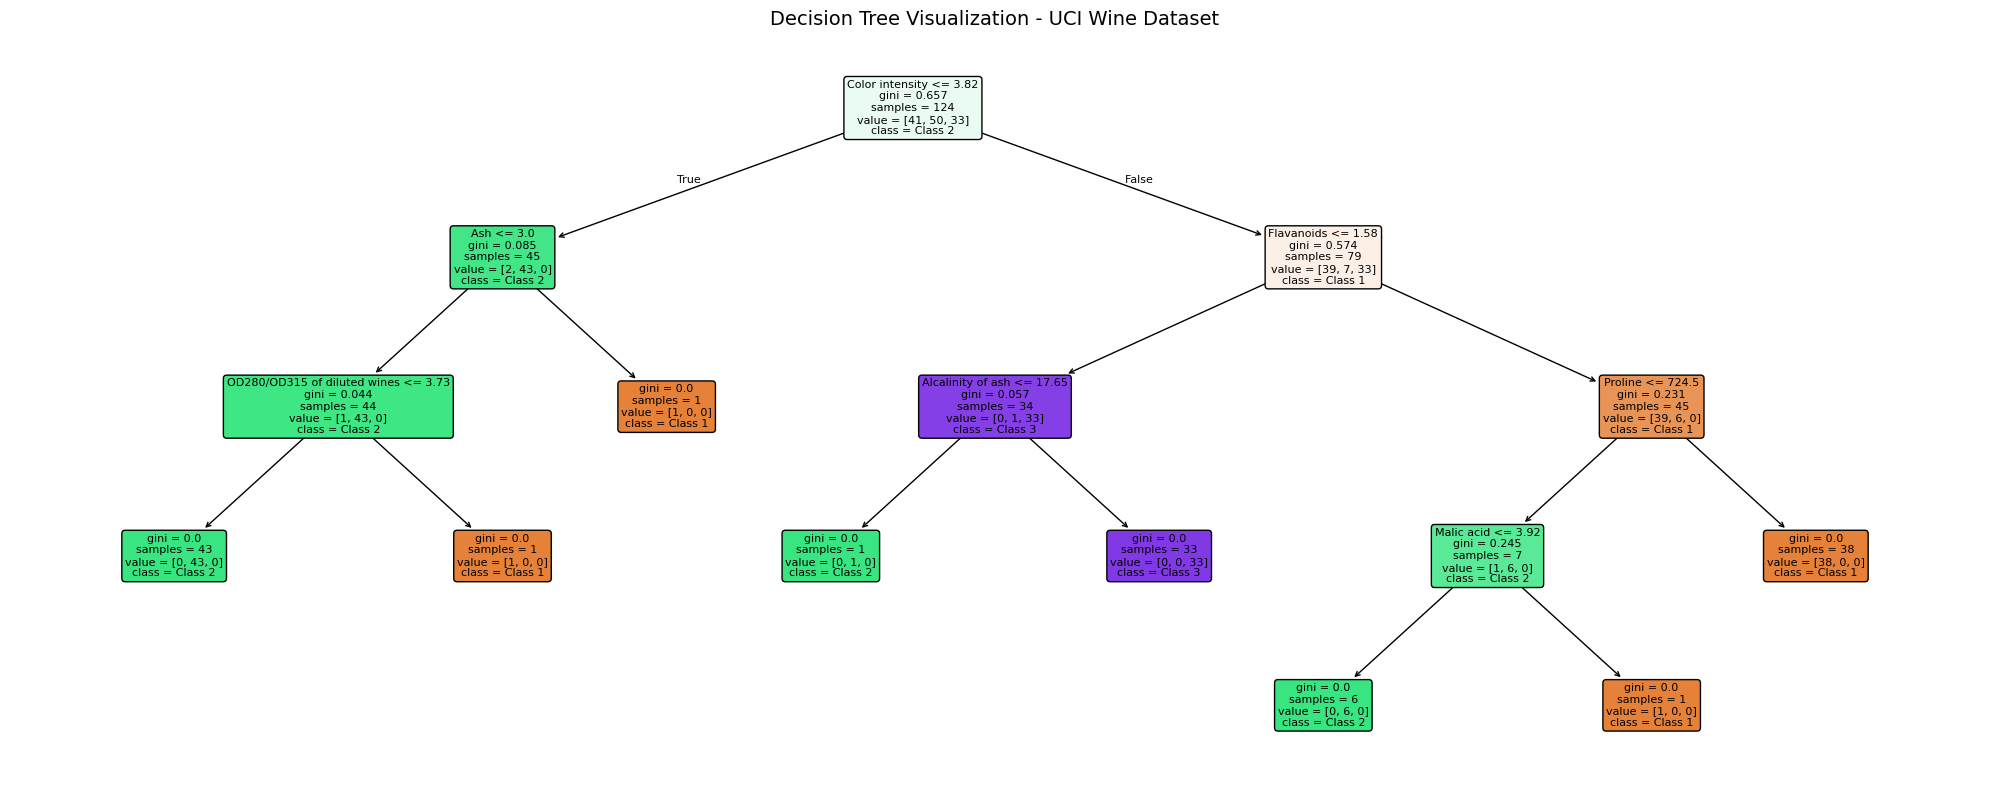

Saved: decision_tree_plot.png


In [15]:
# SECTION 6.2: Explainability - Decision Tree Plot
# Visual representation of tree structure
# Each node shows: split condition, gini impurity, class label
# ----------------------------------------------------------------

plt.figure(figsize=(20, 8))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=[f"Class {c}" for c in np.unique(y)],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization - UCI Wine Dataset", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "decision_tree_plot.png"), dpi=300)
plt.show()
print("Saved: decision_tree_plot.png")

Decision Tree Feature Importance (ranked):
  Flavanoids                          0.4049
  Color intensity                     0.3968
  Proline                             0.1066
  OD280/OD315 of diluted wines        0.0240
  Alcalinity of ash                   0.0238
  Ash                                 0.0229
  Malic acid                          0.0210
  Alcohol                             0.0000
  Magnesium                           0.0000
  Total phenols                       0.0000
  Nonflavanoid phenols                0.0000
  Proanthocyanins                     0.0000
  Hue                                 0.0000


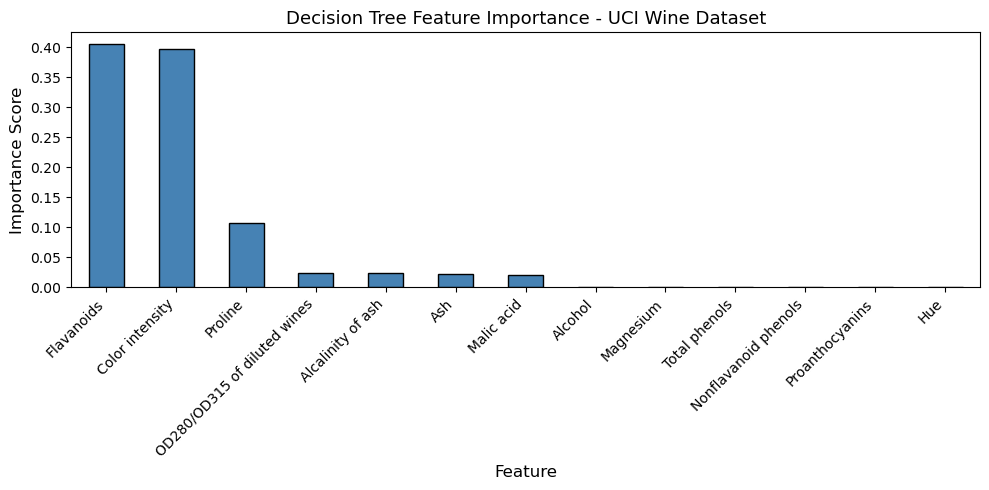

Saved: decision_tree_feature_importance.png


In [16]:
# SECTION 6.3: Explainability - Feature Importance
# Measures how much each feature reduces impurity in the tree
# Higher importance = stronger influence on predictions
# -------------------------------------------------------------

importance = pd.Series(
    tree.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("Decision Tree Feature Importance (ranked):")
for feat, val in importance.items():
    print(f"  {feat:35s} {val:.4f}")

plt.figure(figsize=(10, 5))
importance.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Decision Tree Feature Importance - UCI Wine Dataset", fontsize=13)
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "decision_tree_feature_importance.png"), dpi=300)
plt.show()
print("Saved: decision_tree_feature_importance.png")

Model Performance Summary:
                   Model  Accuracy  F1-macro
Logistic Regression (L1)    0.9815    0.9829
Logistic Regression (L2)    0.9815    0.9829
           Decision Tree    0.9630    0.9638

Saved: metrics_summary.csv


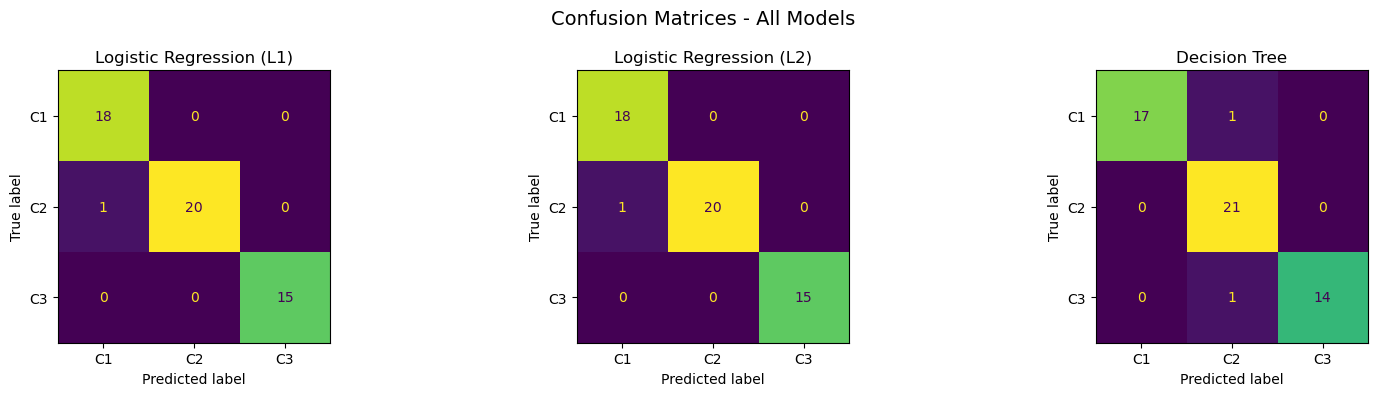

Saved: confusion_matrices.png


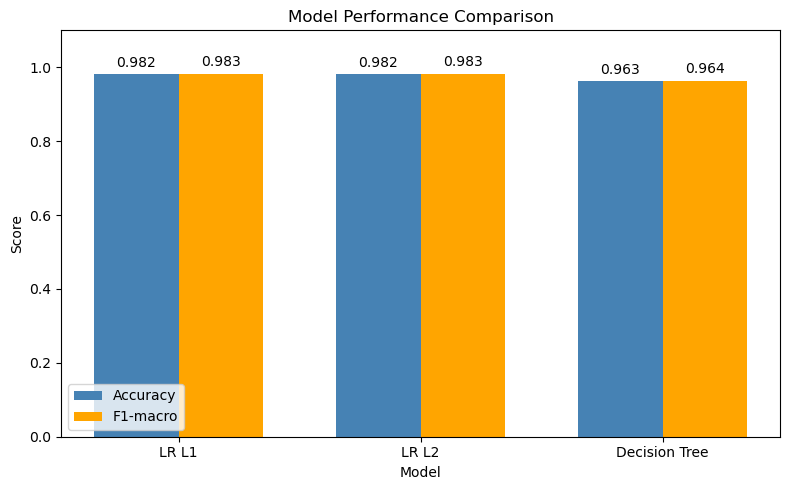

Saved: model_comparison.png


In [17]:
# SECTION 7: Model Performance Comparison
# Compare all 3 models side by side
# Confusion matrices + bar chart + summary table
# ---------------------------------------------------------

# Summary table
results = pd.DataFrame({
    "Model"    : ["Logistic Regression (L1)", "Logistic Regression (L2)", "Decision Tree"],
    "Accuracy" : [round(acc_l1, 4), round(acc_l2, 4), round(acc_tree, 4)],
    "F1-macro" : [round(f1_l1,  4), round(f1_l2,  4), round(f1_tree,  4)]
})
print("Model Performance Summary:")
print(results.to_string(index=False))

results.to_csv(os.path.join(out_dir, "metrics_summary.csv"), index=False)
print("\nSaved: metrics_summary.csv")

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_l1, ax=axes[0], colorbar=False,
    display_labels=[f"C{c}" for c in np.unique(y)]
)
axes[0].set_title("Logistic Regression (L1)")

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_l2, ax=axes[1], colorbar=False,
    display_labels=[f"C{c}" for c in np.unique(y)]
)
axes[1].set_title("Logistic Regression (L2)")

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_tree, ax=axes[2], colorbar=False,
    display_labels=[f"C{c}" for c in np.unique(y)]
)
axes[2].set_title("Decision Tree")

plt.suptitle("Confusion Matrices - All Models", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "confusion_matrices.png"), dpi=300)
plt.show()
print("Saved: confusion_matrices.png")

# Bar chart comparison
x      = np.arange(3)
width  = 0.35
labels = ["LR L1", "LR L2", "Decision Tree"]

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, results["Accuracy"], width, label="Accuracy", color="steelblue")
bars2 = ax.bar(x + width/2, results["F1-macro"], width, label="F1-macro",  color="orange")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=3)
ax.bar_label(bars2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "model_comparison.png"), dpi=300)
plt.show()
print("Saved: model_comparison.png")

In [20]:
# SECTION 8: Final Summary
# List all outputs saved for the report
# --------------------------------------------------
print("Assignment 1 Python Experiment Complete!")
print("-"*60)
print(f"\nAll outputs saved to: {out_dir}/")
print("\nFiles created:")
files = [
    "eda_class_distribution.png",
    "eda_feature_distributions.png",
    "lr_l1_coefficients_heatmap.png",
    "lr_l1_regularization_path.png",
    "decision_tree_rules.txt",
    "decision_tree_plot.png",
    "decision_tree_feature_importance.png",
    "confusion_matrices.png",
    "model_comparison.png",
    "metrics_summary.csv"
]
for f in files:
    print(f"  {f}")

print("\nDone.")

Assignment 1 Python Experiment Complete!
------------------------------------------------------------

All outputs saved to: outputs/

Files created:
  eda_class_distribution.png
  eda_feature_distributions.png
  lr_l1_coefficients_heatmap.png
  lr_l1_regularization_path.png
  decision_tree_rules.txt
  decision_tree_plot.png
  decision_tree_feature_importance.png
  confusion_matrices.png
  model_comparison.png
  metrics_summary.csv

Done.
